In [1]:
# === RandomizedSearchCV untuk Decision Tree (fokus: Recall Churn) ===
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve
)
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
# --- 1) Model baseline sebagai estimator ---
dt = DecisionTreeClassifier(
    random_state=42  # reproducible
    # catatan: parameter lain (max_depth, dll.) akan dicari via random search
)

In [4]:
# --- 2) Ruang pencarian hyperparameter ---
# Penjelasan cepat:
# - max_depth: makin besar -> model makin kompleks (rawan overfit)
# - min_samples_split: min sampel utk memecah node; makin besar -> pohon lebih "hemat"
# - min_samples_leaf: min sampel per daun; makin besar -> smoothing, nolong recall stabil
# - max_features: jumlah fitur yg dipertimbangkan per split; 'sqrt'/'log2' bisa kurangi varians
# - criterion: fungsi impurity; 'gini' cepat, 'entropy/log_loss' kadang lebih akurat
# - class_weight: 'balanced' utk imbangan 3:1 (menekan FN)
# - ccp_alpha: cost-complexity pruning; >0 memangkas cabang kecil (kurangi overfit)
param_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": randint(3, 31),               # 3..30
    "min_samples_split": randint(2, 51),       # 2..50
    "min_samples_leaf": randint(1, 31),        # 1..30
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"],
    "ccp_alpha": uniform(0.0, 0.02),           # pruning ringan (0.0..0.02)
    "splitter": ["best"]                       # boleh tambah "random" kalau mau regularisasi ekstra
}


In [5]:
# --- 3) Skema CV stratified (penting untuk data imbalanced) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# --- 4) RandomizedSearchCV: fokus refit pada RECALL ---
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}


In [7]:

rs_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=80,                 # 60–150 umum; sesuaikan waktu
    scoring=scoring,
    refit="recall",            # pilih model dengan RECALL CV terbaik
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [8]:
# --- 5) Jalankan pencarian ---
rs_dt.fit(X_train, y_train.ravel())

print("Best params (berdasarkan Recall CV):")
print(rs_dt.best_params_)
print("\nSkor CV rata-rata pada best index:")
best_idx = rs_dt.best_index_
for k in scoring.keys():
    print(f"{k:>9}: {rs_dt.cv_results_[f'mean_test_{k}'][best_idx]:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params (berdasarkan Recall CV):
{'ccp_alpha': np.float64(0.012367720186661746), 'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 22, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 38, 'splitter': 'best'}

Skor CV rata-rata pada best index:
   recall: 0.8890
precision: 0.4311
       f1: 0.5805
  roc_auc: 0.8084
 accuracy: 0.6583


In [9]:
# --- 6) Evaluasi pada test set (threshold default 0.5) ---
best_dt = rs_dt.best_estimator_
y_pred = best_dt.predict(X_test)
y_proba = best_dt.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("\nClassification Report - Decision Tree (Tuned):")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


Classification Report - Decision Tree (Tuned):
              precision    recall  f1-score   support

    No Churn       0.92      0.55      0.69      1033
       Churn       0.41      0.87      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.62      1407
weighted avg       0.79      0.64      0.66      1407

ROC-AUC: 0.7880


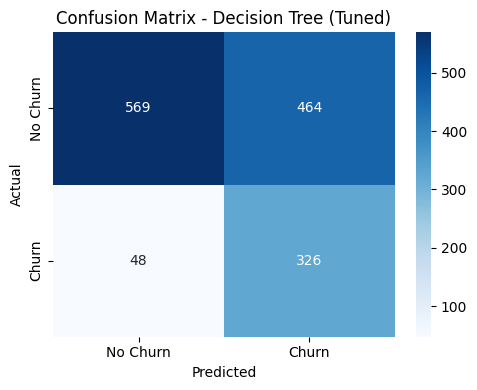

In [10]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Tuned)")
plt.tight_layout()
plt.show()

In [ ]:
# --- 7) (Opsional) Tuning threshold pasca-model untuk kendali FP vs FN ---
# Contoh: pilih threshold dengan recall >= 0.75 dan presisi terbaik
prec, rec, thr = precision_recall_curve(y_test, y_proba)
mask = rec >= 0.75
if np.any(mask):
    best_i = np.argmax(prec[mask])
    best_thr = thr[mask][best_i]
    y_pred_thr = (y_proba >= best_thr).astype(int)
    print(f"\nThreshold optimal (recall>=0.75): {best_thr:.4f}")
    print(confusion_matrix(y_test, y_pred_thr))
    print(classification_report(y_test, y_pred_thr, target_names=["No Churn","Churn"]))